# 1. Did revenue really fall from Q1 to Q2, and by how much, once both sides cover the same weeks?

**Week 1, Tuesday. Chapter 1 of 6.** Monday drew the revenue tree, which writes revenue as customers x orders per customer x revenue per
order, on thirty orders from one window, and ended on the warning of Anand Iyer, Kalpa's finance
controller, that one large order can move an average. Today's export holds both quarters of Kalpa's
year so far, 1 April to 30 September, 200 orders. This chapter builds the first tool of the day, a
dictionary that adds revenue up by a key, and uses it to confirm the drop on windows that match.
Every later chapter grows that tool.

> **The client asks.** "So revenue is customers, times how often they buy, times basket, times
> price. Now: which of those moved? Q2 was Rs 1.9 crore, Q1 was 2.1. Are we losing customers, or
> are the ones we have buying less? Marketing says more customers. Prove it or disprove it."
>
> Meera Raghavan, CEO, Kalpa Retail

**Who needs the answer.** Meera Raghavan, the CEO, has to decide whether Marketing's request for Rs 12 crore to win new
customers is urgent, and the request rests on one slide saying revenue fell by about a quarter. If
the fall is overstated, crores move in a hurry on a lever nobody has checked; if it is understated, a
real leak runs for another quarter.

**The questions on the way.**

1. Which of four ways should size the fall, and what does each leave out?
2. How far did revenue fall between the two closed quarters?
3. Why does Marketing's slide say 25.9 percent?
4. How far apart are the quarters per week, with the window stated?
5. What do the same eleven weeks of each quarter say?
6. Does adding revenue up by month give the same fall?

**The need.** The metric at stake is the change in booked revenue, every order placed before any
cancellation or return, between two quarters, and the decision riding on it is whether the fall is a
crisis that needs money now. Kalpa's financial year opens in April, so Q1 is April to June and Q2 is
July to September, and both quarters had closed by 30 September.

The retail and e-commerce story behind these words is in the domain dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, which tells why a store chain
compares periods like with like before it reads any change.

**Who else faces this.** Avenue Supermarts, which runs DMart, reports like-for-like growth only
on stores that have been open for at least 24 months at the end of the financial year, so a new store
never inflates the comparison; its like-for-like growth was 8.1 percent in FY26 (Avenue Supermarts,
investor presentation, May 2026, checked 30 Sep 2026). Target, in the United States, defines comparable
sales against a prior-year period "of equivalent length": its fiscal 2023 ran 53 weeks against 52, and
it reported that the extra week alone added $1,715 million of sales (Target, fourth quarter and full
year 2023 results, checked 30 Sep 2026). The National Retail Federation's 4-5-4 calendar exists for the
same reason: comparable months hold the same number of weeks and weekends (NRF, checked 30 Sep 2026).

**Setup.** The first lines walk up from this folder until they find the programme's helper, `c2kit`,
and import it as `kit`. The export loads as a list of dictionaries, one per booked order, and `date`
arrives so that a window can be measured in days.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from datetime import date, timedelta   # calendar days, so a window can be measured

ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
print(len(ORDERS), "orders loaded")
print("fields:", ", ".join(ORDERS[0]))

200 orders loaded
fields: order_id, customer_id, segment, channel, city, order_date, amount, status, quarter, discount


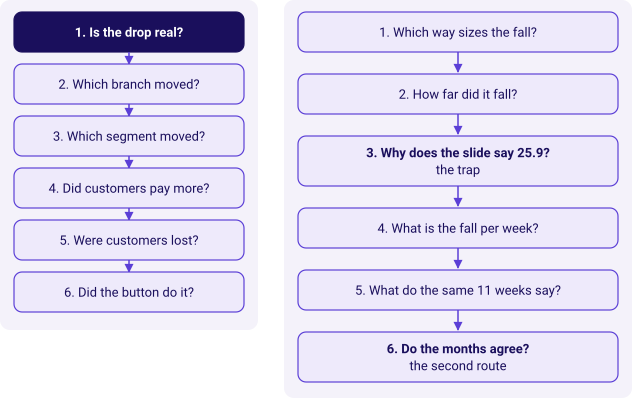

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real?', 'Which branch moved?', 'Which segment moved?', 'Did customers pay more?', 'Were customers lost?', 'Did the button do it?'], lit=0, show=False),
    kit.vflow(['1. Which way sizes the fall?', '2. How far did it fall?', '3. Why does the slide say 25.9?\nthe trap', '4. What is the fall per week?', '5. What do the same 11 weeks say?', '6. Do the months agree?\nthe second route'], show=False),
)

## 1. Which of four ways should size the fall, and what does each leave out?

A team could put a number on "revenue fell" in four ways, each answering a slightly different
question.

| Option | What it compares | What it controls for | What it needs |
|---|---|---|---|
| A. Closed quarters as totals | 1 Apr to 30 Jun against 1 Jul to 30 Sep | The length of the window, once both quarters have closed | Both quarters closed |
| B. The same weeks of both quarters | The first 11 weeks of each | Length and position in the quarter, while a quarter is still open | A cut date |
| C. A rate per week or per day | Revenue divided by the weeks or days each window covers | Length, whatever the windows | The window stated beside the rate |
| D. The same quarter last year | Q2 this year against Q2 last year | Length and the season | Last year's export, which this file does not hold |

On this file each option is sized by the rows it reads, the answer it gives, how far that answer
sits from option A, and what it leaves out.

Option,Rows read,Answer,Gap from A,What it leaves out
A. closed quarters,200,-11.0%,+0.0 points,"nothing, once both quarters have closed"
B. same 11 weeks,167,-17.0%,-6.1 points,"the last two weeks of each quarter, 33 orders"
"C. per day, closed",200,-11.9%,-1.0 points,nothing; it spreads each total over 91 and 92 days
D. same quarter last year,0,cannot run,no last-year rows,"everything, until last year's export arrives"


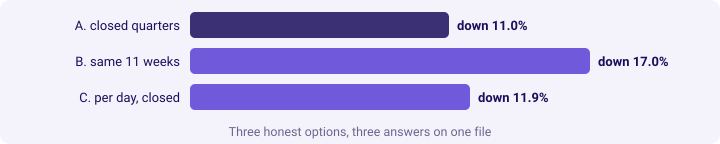

In [3]:
def revenue_between(start, end):
    total, rows = 0, 0
    for order in ORDERS:
        d = date.fromisoformat(order["order_date"])
        if start <= d <= end:
            total += order["amount"]
            rows += 1
    return total, rows

a1, n1 = revenue_between(date(2026, 4, 1), date(2026, 6, 30))
a2, n2 = revenue_between(date(2026, 7, 1), date(2026, 9, 30))
option_a = (a2 - a1) / a1 * 100
b1, m1 = revenue_between(date(2026, 4, 1), date(2026, 6, 16))
b2, m2 = revenue_between(date(2026, 7, 1), date(2026, 9, 15))
option_b = (b2 - b1) / b1 * 100
option_c = (a2 / 92 - a1 / 91) / (a1 / 91) * 100

left_out = len(ORDERS) - (m1 + m2)
rows = [("A. closed quarters", n1 + n2, f"{option_a:.1f}%", "+0.0 points", "nothing, once both quarters have closed"),
        ("B. same 11 weeks", m1 + m2, f"{option_b:.1f}%", f"{option_b - option_a:+.1f} points",
         f"the last two weeks of each quarter, {left_out} orders"),
        ("C. per day, closed", n1 + n2, f"{option_c:.1f}%", f"{option_c - option_a:+.1f} points",
         "nothing; it spreads each total over 91 and 92 days"),
        ("D. same quarter last year", 0, "cannot run", "no last-year rows", "everything, until last year's export arrives")]
kit.table(["Option", "Rows read", "Answer", "Gap from A", "What it leaves out"], rows,
          caption="Four ways to size the fall, on the export as it stands")
kit.bars([("A. closed quarters", round(-option_a, 1)), ("B. same 11 weeks", round(-option_b, 1)),
          ("C. per day, closed", round(-option_c, 1))],
         fmt=lambda v: f"down {v:.1f}%", lit=[0], title="Three honest options, three answers on one file")
kit.check("options A and C read all 200 rows", n1 + n2 == len(ORDERS), f"{n1 + n2}")
kit.check("option B reads fewer rows, because it drops two weeks of each quarter", m1 + m2 < len(ORDERS), f"{m1 + m2}")

On this file option A gives minus 11.0 percent on all 200 rows; option B gives minus 17.0 percent on
167, since it leaves out the last two weeks of each quarter; option C gives minus 11.9 percent per
day; and option D cannot run without last year's export.

**The best-fit call.** Option A, closed quarters as totals, because both quarters had closed by
30 September and each holds thirteen weeks, so the totals already compare like with like and every
reader can rebuild the number from the rows. What separates the options is the question each answers
and what each leaves out, and on a closed pair of quarters A leaves out nothing. **The fact that would
change the call:** if Q2 were still open, option B, the same weeks of both quarters, would take
over; if Meera asked whether the monsoon explains the fall, only option D answers, and it needs last
year's export.

## 2. How far did revenue fall between the two closed quarters?

A dictionary keyed by quarter collects revenue and orders in one pass. A key that is new starts at
zero, and every order adds to its own quarter's total. This accumulator is the tool the whole day
grows.

**Predict before you run.** On the two closed quarters, how far did revenue move? a) it fell about
26 percent; b) it fell about 11 percent; c) it fell about 5 percent; d) it rose.

Quarter,Window,Orders,Revenue
Q1,"1 Apr to 30 Jun, 13 weeks",114,"Rs 2,10,00,000"
Q2,"1 Jul to 30 Sep, 13 weeks",86,"Rs 1,87,00,000"


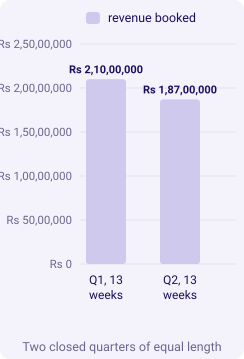

In [4]:
revenue = {}     # quarter -> rupees booked
orders = {}      # quarter -> number of orders
for order in ORDERS:
    q = order["quarter"]
    if q not in revenue:
        revenue[q] = 0
        orders[q] = 0
    revenue[q] += order["amount"]
    orders[q] += 1

change = (revenue["Q2"] - revenue["Q1"]) / revenue["Q1"] * 100
kit.table(["Quarter", "Window", "Orders", "Revenue"],
          [("Q1", "1 Apr to 30 Jun, 13 weeks", orders["Q1"], kit.rupees(revenue["Q1"])),
           ("Q2", "1 Jul to 30 Sep, 13 weeks", orders["Q2"], kit.rupees(revenue["Q2"]))],
          caption=f"Booked orders by quarter: revenue moved {change:.1f} percent")
kit.columns(["Q1, 13 weeks", "Q2, 13 weeks"], [("revenue booked", [revenue["Q1"], revenue["Q2"]])],
            fmt=kit.rupees, title="Two closed quarters of equal length")

**What happened.** The answer is b. Revenue fell from Rs 2,10,00,000 to Rs 1,87,00,000, which is
Rs 23,00,000 less and 11.0 percent down, on two windows of thirteen weeks. That is the number Meera's
question starts from, and it is less than half the fall on Marketing's slide.

In [5]:
kit.check("every order sits in one of the two quarters", orders["Q1"] + orders["Q2"] == len(ORDERS),
          f'{orders["Q1"]} + {orders["Q2"]} = {len(ORDERS)}')
kit.check("the closed-quarter change rounds to minus 11.0 percent", round(change, 1) == -11.0, f"{change:.2f}")
kit.check("the accumulator agrees with option A in the sizing cell", round(change, 6) == round(option_a, 6))

## 3. Why does Marketing's slide say 25.9 percent?

Marketing's deck reads the Q2 figure from the dashboard tile, which somebody screenshotted on
15 September, and sets it against the whole of Q1.

**Predict before you run.** Marketing's slide says revenue fell by about a quarter. What do you
check first? a) the segment mix of each quarter; b) the median order in each quarter; c) the first
and last date inside each window; d) whether discounts changed.

**The plausible wrong answer.** A hurried analyst takes the tile's number as Q2 and divides.

In [6]:
TILE_CUT = "2026-09-15"     # the day the dashboard tile was read

tile_revenue = 0
tile_orders = 0
for order in ORDERS:
    if order["quarter"] == "Q2" and order["order_date"] <= TILE_CUT:
        tile_revenue += order["amount"]
        tile_orders += 1

wrong = (tile_revenue - revenue["Q1"]) / revenue["Q1"] * 100
kit.stats([(kit.rupees(tile_revenue), "Q2 on the tile", f"{tile_orders} orders to 15 September"),
           (kit.rupees(revenue["Q1"]), "Q1, whole quarter", f'{orders["Q1"]} orders'),
           (f"{wrong:.1f}%", "Marketing's change", "the tile against the whole of Q1")])

**Why it is wrong.** The answer to the prediction is c. The tile stopped on 15 September, so its
window holds eleven weeks of trading, and it is set against thirteen. Two weeks of Q2 that nobody had
counted yet show up as lost revenue. Read as a crisis, a 25.9 percent fall pushes Meera to release
the Rs 12 crore acquisition budget in a hurry, on a gap that is mostly the calendar.

**The check.** For each window, print where it starts and ends, the first and last order inside it,
and the weeks it covers.

Window,Covers,First order,Last order,Days,Whole weeks
"Q1, whole quarter",01 Apr to 30 Jun,01 Apr,27 Jun,91,13
Q2 on the tile,01 Jul to 15 Sep,02 Jul,15 Sep,77,11
"Q2, whole quarter",01 Jul to 30 Sep,02 Jul,28 Sep,92,13


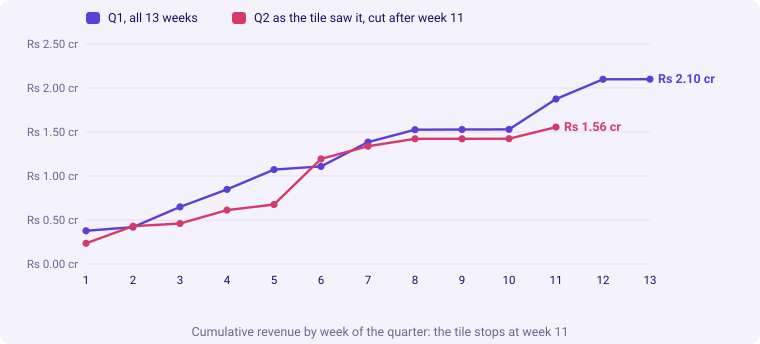

In [7]:
windows = {
    "Q1, whole quarter": (date(2026, 4, 1), date(2026, 6, 30), "Q1"),
    "Q2 on the tile":    (date(2026, 7, 1), date(2026, 9, 15), "Q2"),
    "Q2, whole quarter": (date(2026, 7, 1), date(2026, 9, 30), "Q2"),
}
first, last, days = {}, {}, {}
rows = []
for name in windows:
    start, end, q = windows[name]
    for order in ORDERS:
        d = date.fromisoformat(order["order_date"])
        if order["quarter"] == q and start <= d <= end:
            first[name] = min(first.get(name, d), d)
            last[name] = max(last.get(name, d), d)
    days[name] = (end - start).days + 1
    rows.append((name, f"{start:%d %b} to {end:%d %b}", f"{first[name]:%d %b}", f"{last[name]:%d %b}",
                 days[name], days[name] // 7))
kit.table(["Window", "Covers", "First order", "Last order", "Days", "Whole weeks"], rows,
          caption="The check: where each side of the comparison starts and stops")

start = {"Q1": date(2026, 4, 1), "Q2": date(2026, 7, 1)}
weekly = {"Q1": [0] * 13, "Q2": [0] * 13}      # revenue by week of the quarter
for order in ORDERS:
    q = order["quarter"]
    week = (date.fromisoformat(order["order_date"]) - start[q]).days // 7
    weekly[q][min(week, 12)] += order["amount"]
cumulative = {"Q1": [], "Q2": []}
for q in cumulative:
    running = 0
    for amount in weekly[q]:
        running += amount
        cumulative[q].append(running)
tile_line = cumulative["Q2"][:11] + [None, None]
kit.line([str(w) for w in range(1, 14)],
         [("Q1, all 13 weeks", cumulative["Q1"], "plain"),
          ("Q2 as the tile saw it, cut after week 11", tile_line, "bad")],
         fmt=lambda v: f"Rs {v / 1e7:.2f} cr",
         title="Cumulative revenue by week of the quarter: the tile stops at week 11")
kit.check("Q1 covers 13 whole weeks and the tile 11", (days["Q1, whole quarter"] // 7, days["Q2 on the tile"] // 7) == (13, 11))
kit.check("Marketing's figure rounds to minus 25.9 percent", round(wrong, 1) == -25.9, f"{wrong:.2f}")

**The fix.** Compare the closed quarters, thirteen weeks each: minus 11.0 percent, Rs 23,00,000.
Marketing's extra fall is Q2's last two weeks, which the tile had not reached: they carried
Rs 31,40,050 of revenue, and the bridge walks from Q1 to Q2 in those two steps.

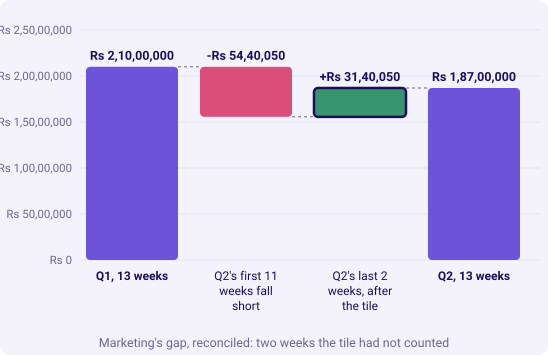

In [8]:
late = revenue["Q2"] - tile_revenue
kit.bridge(("Q1, 13 weeks", revenue["Q1"]),
           [("Q2's first 11 weeks fall short", tile_revenue - revenue["Q1"]),
            ("Q2's last 2 weeks, after the tile", late)],
           end_label="Q2, 13 weeks", lit=[1],
           title="Marketing's gap, reconciled: two weeks the tile had not counted")
kit.check("the bridge lands on the closed Q2 total", revenue["Q1"] + (tile_revenue - revenue["Q1"]) + late == revenue["Q2"],
          kit.rupees(revenue["Q2"]))
kit.check("the uncounted weeks hold 16 orders and Rs 31,40,050", (orders["Q2"] - tile_orders, late) == (16, 3140050),
          f'{orders["Q2"] - tile_orders} orders, {kit.rupees(late)}')

**What changed.** The fall Meera is asked to act on shrank from Rs 54,40,050 to Rs 23,00,000, and
from 25.9 percent to 11.0 percent. Sixteen orders worth Rs 31,40,050 came in after the tile was
read.

## 4. How far apart are the quarters per week, with the window stated?

This is option C at work. A rate per week puts windows of different length on one scale, provided
the rate says what was counted, what it was divided by, and over which dates.

**Predict before you run.** Revenue per week, Q1's thirteen weeks against the tile's eleven: how far
apart are they? a) minus 25.9 percent, the same as the totals; b) minus 12.4 percent; c) no change;
d) plus 5 percent.

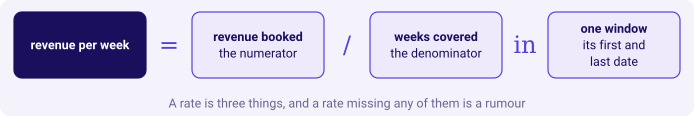

Rate,Numerator,Denominator,Window,Value
Q1 revenue per week,"Rs 2,10,00,000",13 weeks,1 Apr to 30 Jun,"Rs 16,15,385"
"Q2 revenue per week, tile","Rs 1,55,59,950",11 weeks,1 Jul to 15 Sep,"Rs 14,14,541"


In [9]:
per_week_q1 = revenue["Q1"] / 13
per_week_tile = tile_revenue / 11
per_week_change = (per_week_tile - per_week_q1) / per_week_q1 * 100
kit.equation(["revenue per week", "=", "revenue booked\nthe numerator", "/",
              "weeks covered\nthe denominator", "in", "one window\nits first and last date"],
             title="A rate is three things, and a rate missing any of them is a rumour")
kit.table(["Rate", "Numerator", "Denominator", "Window", "Value"],
          [("Q1 revenue per week", kit.rupees(revenue["Q1"]), "13 weeks", "1 Apr to 30 Jun", kit.rupees(round(per_week_q1))),
           ("Q2 revenue per week, tile", kit.rupees(tile_revenue), "11 weeks", "1 Jul to 15 Sep", kit.rupees(round(per_week_tile)))],
          caption=f"Per week on the cut window: {per_week_change:.1f}%")
kit.check("revenue per week falls 12.4 percent on the cut window", round(per_week_change, 1) == -12.4, f"{per_week_change:.2f}")
kit.check("per day on the closed quarters, the fall is 11.9 percent", round(option_c, 1) == -11.9, f"{option_c:.2f}")

**What happened.** The answer is b. Per week, the tile's eleven weeks sit 12.4 percent below Q1, at
Rs 14,14,541 a week against Rs 16,15,385. On the closed quarters per day the fall is 11.9 percent,
because Q2 has 92 days and Q1 has 91. Each figure is honest because it says what it divided and over
which dates, and none of them is 25.9 percent.

## 5. What do the same eleven weeks of each quarter say?

This is option B at work. Suppose Q2 were still open on 15 September: the like-with-like comparison
is then the first eleven weeks of each quarter, 1 April to 16 June against 1 July to 15 September.

**Predict before you run.** Q1's first eleven weeks against Q2's first eleven weeks: a) minus
12.4 percent, the same as the per-week rate; b) minus 11.0 percent, the same as the closed quarters;
c) a fall larger than both; d) a rise.

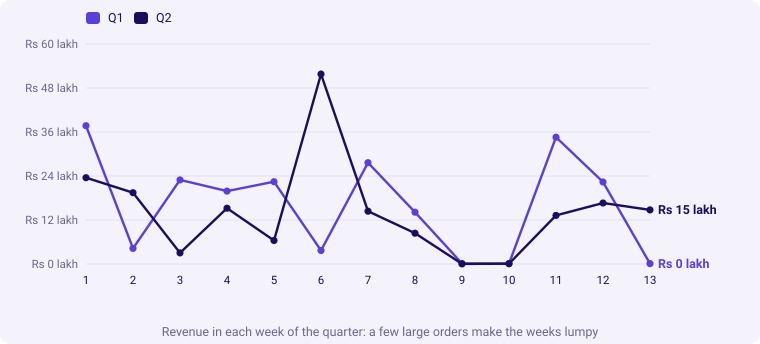

Window,Orders,Revenue
"Q1, 1 Apr to 16 Jun",97,"Rs 1,87,51,440"
"Q2, 1 Jul to 15 Sep",70,"Rs 1,55,59,950"


In [10]:
kit.line([str(w) for w in range(1, 14)],
         [("Q1", weekly["Q1"], "plain"), ("Q2", weekly["Q2"], "lit")],
         fmt=lambda v: f"Rs {v / 1e5:.0f} lakh",
         title="Revenue in each week of the quarter: a few large orders make the weeks lumpy")
kit.table(["Window", "Orders", "Revenue"],
          [("Q1, 1 Apr to 16 Jun", m1, kit.rupees(b1)), ("Q2, 1 Jul to 15 Sep", m2, kit.rupees(b2))],
          caption=f"The same eleven weeks of each quarter: {option_b:.1f}%")
kit.check("the same-weeks comparison is minus 17.0 percent", round(option_b, 1) == -17.0, f"{option_b:.2f}")
kit.check("the weekly figures add back to each quarter's total",
          sum(weekly["Q1"]) == revenue["Q1"] and sum(weekly["Q2"]) == revenue["Q2"])

**What happened.** The answer is c. The same eleven weeks give minus 17.0 percent. That differs from
the per-week minus 12.4 because Kalpa's weekly revenue is lumpy: a week with no large business order
books ten or fifteen thousand rupees, and a week with three of them books lakhs, so which weeks a cut
happens to include moves the answer. Once a quarter has closed, compare closed quarters; a
quarter-to-date comparison uses the same weeks of both quarters and says so.

## 6. Does adding revenue up by month give the same fall?

The accumulator keyed by quarter trusted the `quarter` field in each record. A second route ignores
that field, keys the accumulator by the month in `order_date`, and adds the months back into
quarters. If the two routes disagree, one of them is reading the file wrongly.

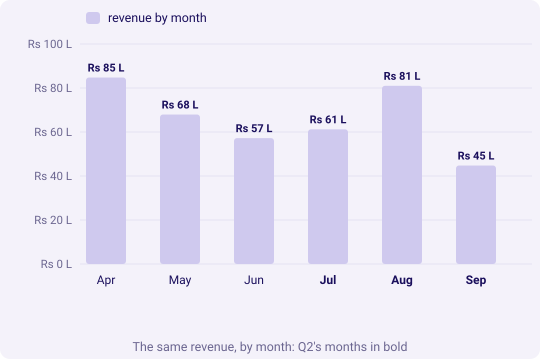

In [11]:
by_month = {}
for order in ORDERS:
    month = order["order_date"][:7]          # "2026-04"
    by_month[month] = by_month.get(month, 0) + order["amount"]

q1_months = by_month["2026-04"] + by_month["2026-05"] + by_month["2026-06"]
q2_months = by_month["2026-07"] + by_month["2026-08"] + by_month["2026-09"]
route_two = (q2_months - q1_months) / q1_months * 100
kit.columns(["Apr", "May", "Jun", "Jul", "Aug", "Sep"], [("revenue by month", [by_month[m] for m in sorted(by_month)])],
            fmt=lambda v: f"Rs {v / 1e5:.0f} L", lit=[3, 4, 5], title="The same revenue, by month: Q2's months in bold")
kit.check("the months add to the same Q1 and Q2 totals", (q1_months, q2_months) == (revenue["Q1"], revenue["Q2"]),
          f"{kit.rupees(q1_months)} and {kit.rupees(q2_months)}")
kit.check("both routes give minus 11.0 percent", round(route_two, 6) == round(change, 6), f"{route_two:.2f}")

The two routes agree: April to June add to Rs 2,10,00,000 and July to September to Rs 1,87,00,000,
minus 11.0 percent both ways.

**When to switch.** Keep the quarter key for the headline; switch to the month key when the question
moves inside the quarter, as it will in chapter 6, where the head of Retail-Plus dates a cause to a
week in August.

Kavya Nair, the team's senior analyst, reviews every number before it leaves.

> **Kavya's review.** "Marketing's arithmetic was correct on a quarter that had not finished. Say
> both windows out loud with their first and last dates before you say a percentage, and say which
> option you picked and what would make you pick another. Unmatched windows make every later number
> wrong."

### In the interview: how would you investigate a sales drop, and when is a quarter-on-quarter comparison fair?

The tags mark how often a question comes up: [S] a staple asked everywhere, [F] frequent in GCC and product screens, [SV] a service-major screen opener, [D] a differentiator.

**[S] Sales dropped 15 percent last month; how would you investigate?** "I work in a fixed order.
First I confirm the drop is real: the same window on both sides, closed periods or the same days of each,
the same definition of a sale, and an export that is complete. Then I decompose revenue along a
tree, customers times orders per customer times revenue per order, and see which branch moved. Then
I split the moving branch by segment, and inside a segment I check whether a mix shift or a real
change in rate is behind it. Only then do I name a cause, as a hypothesis, with the evidence that
would settle it, and timing is the first test: a cause cannot come after its effect." The
interviewer is listening for the order, and above all for the first step, which most candidates skip.

**[F] What has to match before a quarter-on-quarter comparison is fair?** "Four things have to
match: the window, the definition, the population and the denominator, all on an export pulled after
the later period closed. The windows must be the same length with both periods closed; if one is
still open, I compare the same weeks of each and state a rate per week beside them, since a rate
fixes the length of the windows and leaves their position. What is
counted, booked or delivered, must be the same on both sides, and so must the segments and customers
in scope and the denominator behind any rate. Today a dashboard tile read on 15 September and set
against a full quarter turned an 11.0 percent fall into 25.9." The
interviewer is listening for window, definition, population and denominator named without prompting.

**The design question. Q2 is still open; which comparison do you send, and what would make you
switch?** "The same weeks of both quarters, with the cut date in the sentence, because it controls
for length and for where in the quarter the weeks sit, and a rate per week beside it. On Kalpa's
file those two disagree, minus 17.0 against minus 12.4, because a few business orders make weeks
lumpy, so I say both and wait for the close. I switch to closed quarters the day the quarter closes,
and to the same quarter last year if the question becomes the season." The interviewer is listening
for a choice, its reason, and the fact that would change it.

### Depth: could a weekend or a festival make two windows of equal length unequal?

Weeks and days are only the first level of matching. A quarter can hold one more weekend than
another, or a festival that falls in a different month from one year to the next, and a business
that trades mostly on weekends then shows a change that is only the calendar. Try it here: count the
Saturdays and Sundays in each quarter with `date` and `timedelta`, and decide whether Kalpa's gap
could be a weekend effect.

References for the chapter:

- Brit Institute, data analyst case study questions, including "Sales dropped last month. How would you investigate?": https://britinstitute.uk/blog/data-analyst-case-study-interview-questions (verified 29 Sep 2026)
- Exponent, data analyst interview questions: https://www.tryexponent.com/blog/top-data-analyst-interview-questions (verified 29 Sep 2026)

## So, is the drop real?

1. Of the four ways to size the fall, closed quarters as totals give minus 11.0 percent on all 200 rows, the same 11 weeks of each quarter minus 17.0 percent on 167 rows, a rate per day minus 11.9 percent, and the same quarter last year cannot run without last year's export.
2. Revenue fell from Rs 2,10,00,000 to Rs 1,87,00,000 between the two closed quarters: Rs 23,00,000 less, minus 11.0 percent, on 13 weeks each.
3. Marketing's slide says 25.9 percent because its Q2 is a dashboard tile cut on 15 September, 11 weeks against Q1's 13, and the two weeks the tile never saw held 16 orders and Rs 31,40,050.
4. Per week the quarters sit 12.4 percent apart, Rs 14,14,541 a week on the tile against Rs 16,15,385, and per day the closed quarters sit 11.9 percent apart.
5. The same eleven weeks of each quarter say minus 17.0 percent, because a few large orders make weeks lumpy, so once a quarter closes the closed quarters are compared.
6. Adding revenue up by month gives the same fall: April to June add to Rs 2,10,00,000 and July to September to Rs 1,87,00,000, minus 11.0 percent both ways.

Yes, the drop is real. Revenue fell 11.0 percent, Rs 23,00,000, between two closed quarters of 13 weeks
each, and Marketing's 25.9 percent compared 11 weeks with 13.

In [12]:
kit.check_summary()
print("Next, chapter 2. Which branch of the revenue tree carries the Rs 23,00,000 fall: customers, how "
      "often they buy, or what each order is worth?")

Next, chapter 2. Which branch of the revenue tree carries the Rs 23,00,000 fall: customers, how often they buy, or what each order is worth?
